# 02-Resource Management & Autoscaling (Kubernetes HPA/VPA)

Lesson 01 established the static half of resource management: a Pod declares a fixed CPU/memory request vector $r_p$, and `kube-scheduler` bin-packs it onto a node exactly once, at creation time. That model works perfectly for a cluster with constant load, but real traffic is never constant — a recommendation API might see 5x the request volume at 9 a.m. than at 3 a.m., and a batch training job might spike memory usage tenfold during a single epoch boundary.

Static placement cannot react to that. This lesson introduces the **dynamic** half of resource management: controllers that continuously watch live metrics and rewrite the desired state itself, rather than merely enforcing it. The **Horizontal Pod Autoscaler (HPA)** changes *how many* replicas exist in response to observed load; the **Vertical Pod Autoscaler (VPA)** changes *how large* each replica's resource request is, based on its own historical usage distribution. Both are Kubernetes control loops in the sense of Lesson 01, just with a metrics-server feedback signal replacing a human's `kubectl scale` command.

We will implement the exact scaling arithmetic Kubernetes uses internally — the HPA ratio formula with its stabilization tolerance, and the VPA percentile-based recommender — using the **Kubernetes autoscaling/v2 API** semantics, wrapped for a sandbox that has no live metrics-server.

## 1. The Control-Theoretic Physics of Autoscaling

### The HPA Ratio Control Law

The HPA controller polls the metrics API every sync period (default 15s) and computes the desired replica count as a proportional control law. Given the current replica count $R_c$, the observed average metric value $M_{cur}$ (e.g. CPU utilization across all pods), and the target value $M_{tgt}$ configured on the HPA object:

$$R_{desired} = \left\lceil R_c \times \frac{M_{cur}}{M_{tgt}} \right\rceil$$

This is a discrete proportional controller: if utilization is double the target, replicas double; if utilization is at target, replicas are unchanged. To prevent oscillation from sensor noise, Kubernetes applies a **tolerance band** $\tau$ (default $0.1$) around the target — the controller only acts if the ratio deviates enough to matter:

$$\text{Scale} \iff \left| \frac{M_{cur}}{M_{tgt}} - 1 \right| > \tau$$

### Stabilization Windows and Anti-Flapping

A raw proportional law thrashes under bursty load (scale up, then immediately scale down on the next noisy sample). The HPA algorithm guards against this with a **stabilization window** $W$: on scale-down decisions specifically, it looks back over the last $W$ seconds of *desired* replica computations and picks the **maximum** value seen in that window:

$$R_{desired}^{stable}(t) = \max_{t - W \le s \le t} R_{desired}(s)$$

This makes scale-up reactive (fast) while making scale-down conservative (slow) — a deliberately asymmetric control law, because under-provisioning causes user-facing latency while over-provisioning only costs money.

### The VPA Percentile Recommender

Where HPA changes replica *count*, VPA changes each Pod's resource *request* $r_p$. The VPA Recommender maintains a decaying histogram of observed usage samples $u_1, u_2, \dots, u_T$ per container and computes a **target recommendation** as a high percentile of that distribution plus a safety margin $\epsilon$:

$$r_p^{VPA} = P_{90}(u_1, \dots, u_T) \times (1 + \epsilon)$$

Using $P_{90}$ rather than the mean deliberately over-provisions relative to typical usage, trading some efficiency for a low probability that a burst exceeds the request (which would trigger CPU throttling, or worse, an OOM kill if it were a hard limit).

### CFS Quota Throttling vs. OOM Kill: Two Different Failure Modes

Kubernetes enforces `limits.cpu` via the Completely Fair Scheduler (CFS) quota mechanism: a container gets a quota $Q = \text{cpu\_limit} \times \text{period}$ (period is typically $100ms$) of CPU-time per period. If cumulative usage exceeds $Q$ within a period, the kernel throttles the cgroup for the remainder of that period — a *soft*, recoverable degradation:

$$\text{ThrottleRatio} = \frac{\text{Throttled Periods}}{\text{Total Periods}}$$

Memory has no equivalent soft mechanism: `limits.memory` is a hard ceiling enforced by the kernel's cgroup OOM killer. The instant resident set size exceeds the limit, the process is `SIGKILL`ed — a *hard*, unrecoverable failure. This asymmetry is exactly why VPA's safety margin $\epsilon$ matters more for memory requests than CPU requests.

## 2. Imperative Execution: Simulating the HPA Control Loop and VPA Recommender

We construct a real `HorizontalPodAutoscaler` (autoscaling/v2) manifest, then drive a synthetic 48-step load trace through the exact ratio + tolerance + stabilization-window algorithm described above, since no live metrics-server exists in this sandbox.

In [1]:
# Required installations: pip install kubernetes pyyaml numpy

import numpy as np
import yaml
import math

print("--- 🚀 Initializing HPA/VPA Autoscaling Control-Loop Sandbox ---")

rng = np.random.default_rng(42)

# 1. Author a real HorizontalPodAutoscaler manifest (autoscaling/v2), exactly what `kubectl apply -f` ingests
hpa_manifest = {
    "apiVersion": "autoscaling/v2",
    "kind": "HorizontalPodAutoscaler",
    "metadata": {"name": "api-backend-hpa", "namespace": "ml-workloads"},
    "spec": {
        "scaleTargetRef": {"apiVersion": "apps/v1", "kind": "Deployment", "name": "api-backend"},
        "minReplicas": 2,
        "maxReplicas": 12,
        "behavior": {"scaleDown": {"stabilizationWindowSeconds": 60}},
        "metrics": [{
            "type": "Resource",
            "resource": {"name": "cpu", "target": {"type": "Utilization", "averageUtilization": 50}},
        }],
    },
}
with open("hpa.yaml", "w") as f:
    yaml.dump(hpa_manifest, f, sort_keys=False)
print("   ✅ HorizontalPodAutoscaler manifest (target=50% CPU, min=2, max=12) compiled to hpa.yaml")

# 2. Synthesize a 48-step diurnal load trace (percent CPU utilization averaged across current replicas)
TARGET_UTIL = 50.0
TOLERANCE = 0.10
MIN_REPLICAS, MAX_REPLICAS = 2, 12
STAB_WINDOW = 4  # steps of look-back for scale-down stabilization

steps = np.arange(48)
diurnal = 55 + 40 * np.sin((steps / 48) * 2 * np.pi - np.pi / 2)
noise = rng.normal(0, 6, size=48)
observed_util = np.clip(diurnal + noise, 5, 100)

print("\n--- 🧮 Executing HPA Control Loop (Ratio Law + Tolerance + Stabilization Window) ---")

try:
    from kubernetes import client, config
    config.load_kube_config()
    autoscaling_v2 = client.AutoscalingV2Api()
    hpa_list = autoscaling_v2.list_namespaced_horizontal_pod_autoscaler("ml-workloads")
    print(f"   Connected to live cluster with {len(hpa_list.items)} HPA objects.")
except Exception as e:
    print("   [SYSTEM NOTE]: No live metrics-server reachable in this sandbox -- replaying the HPA ratio")
    print("   control law against the synthetic 48-step diurnal load trace.")

    replicas = MIN_REPLICAS
    desired_history = []
    replica_history = []
    action_history = []

    for t, util in enumerate(observed_util):
        raw_desired = math.ceil(replicas * (util / TARGET_UTIL))
        raw_desired = int(np.clip(raw_desired, MIN_REPLICAS, MAX_REPLICAS))
        desired_history.append(raw_desired)

        # Stabilization window: on scale-down, take the MAX of the last W desired values (anti-flap)
        window = desired_history[max(0, t - STAB_WINDOW + 1):t + 1]
        stable_desired = max(window)

        ratio = util / TARGET_UTIL
        if abs(ratio - 1.0) <= TOLERANCE:
            action = "no-op (within tolerance)"
        elif stable_desired > replicas:
            action = f"SCALE UP {replicas}->{stable_desired}"
            replicas = stable_desired
        elif stable_desired < replicas:
            action = f"SCALE DOWN {replicas}->{stable_desired}"
            replicas = stable_desired
        else:
            action = "no-op"

        replica_history.append(replicas)
        action_history.append(action)

    print(f"   ✅ Simulated {len(steps)} control-loop ticks. Final replica count: {replicas}")

# 3. VPA percentile recommender over a separate, independent usage-sample trace (mCPU per pod)
print("\n--- 🧮 Executing VPA Percentile Recommender ---")
usage_samples_mcpu = rng.gamma(shape=4.0, scale=90, size=500)  # right-skewed usage distribution
p50 = np.percentile(usage_samples_mcpu, 50)
p90 = np.percentile(usage_samples_mcpu, 90)
safety_margin = 0.15
vpa_recommendation_mcpu = p90 * (1 + safety_margin)
print(f"   Observed usage: P50={p50:.0f}m, P90={p90:.0f}m over {len(usage_samples_mcpu)} samples")
print(f"   ✅ VPA target recommendation (P90 x 1.15 safety margin): {vpa_recommendation_mcpu:.0f}m CPU")


--- 🚀 Initializing HPA/VPA Autoscaling Control-Loop Sandbox ---
   ✅ HorizontalPodAutoscaler manifest (target=50% CPU, min=2, max=12) compiled to hpa.yaml

--- 🧮 Executing HPA Control Loop (Ratio Law + Tolerance + Stabilization Window) ---
   [SYSTEM NOTE]: No live metrics-server reachable in this sandbox -- replaying the HPA ratio
   control law against the synthetic 48-step diurnal load trace.
   ✅ Simulated 48 control-loop ticks. Final replica count: 5

--- 🧮 Executing VPA Percentile Recommender ---
   Observed usage: P50=332m, P90=596m over 500 samples
   ✅ VPA target recommendation (P90 x 1.15 safety margin): 685m CPU


## 3. Declarative Telemetry: The Autoscaling Decision Audit

We audit a representative slice of the control-loop trace exactly as `kubectl describe hpa api-backend-hpa` would surface its recent scaling events, alongside the VPA recommendation delta against the original static request from Lesson 01.

In [2]:
print("\n--- 🔍 Auditing the HPA Decision Trace (Steps 0-15) ---")
print(f"{'Step':<6} | {'CPU Util %':<11} | {'Raw Desired':<12} | {'Stable Desired':<15} | {'Action'}")
print("-" * 80)
for t in range(16):
    print(f"{t:<6} | {observed_util[t]:>9.1f}  | {desired_history[t]:<12} | {replica_history[t]:<15} | {action_history[t]}")

print("\n[OPERATIONAL INSIGHT]")
print("-> The raw ratio law fires almost every step because noise constantly nudges the ratio outside the")
print("   +/-10% tolerance band -- the stabilization window is what prevents visible replica flapping.")
print("-> Scale-UP reacts within a single tick (fast, protects latency); scale-DOWN is damped by the")
print(f"   {STAB_WINDOW}-step max-lookback window (slow, protects against premature de-provisioning).")
print(f"-> VPA's P90-based recommendation ({vpa_recommendation_mcpu:.0f}m) sits {(vpa_recommendation_mcpu/p50 - 1)*100:.0f}% above the")
print("   median usage sample -- intentionally over-provisioning to absorb bursts without CFS throttling.")
print("-> HPA and VPA target the SAME container's CPU dimension by design should never run together on one")
print("   metric: HPA would fight VPA's request rewrites, each interpreting the other's action as new load.")



--- 🔍 Auditing the HPA Decision Trace (Steps 0-15) ---
Step   | CPU Util %  | Raw Desired  | Stable Desired  | Action
--------------------------------------------------------------------------------
0      |      16.8  | 2            | 2               | no-op
1      |       9.1  | 2            | 2               | no-op
2      |      20.9  | 2            | 2               | no-op
3      |      23.7  | 2            | 2               | no-op
4      |       8.7  | 2            | 2               | no-op
5      |      15.5  | 2            | 2               | no-op
6      |      27.5  | 2            | 2               | no-op
7      |      28.8  | 2            | 2               | no-op
8      |      34.9  | 2            | 2               | no-op
9      |      34.6  | 2            | 2               | no-op
10     |      49.9  | 2            | 2               | no-op (within tolerance)
11     |      54.4  | 3            | 2               | no-op (within tolerance)
12     |      55.4  | 3       

## 4. Visualizing the Reactive Control Loop (Load vs. Replica Step Response)

We plot the observed CPU utilization trace against the HPA's target threshold on one axis, and the resulting replica count as a step function on a second axis -- the canonical way to see a feedback controller's step response.

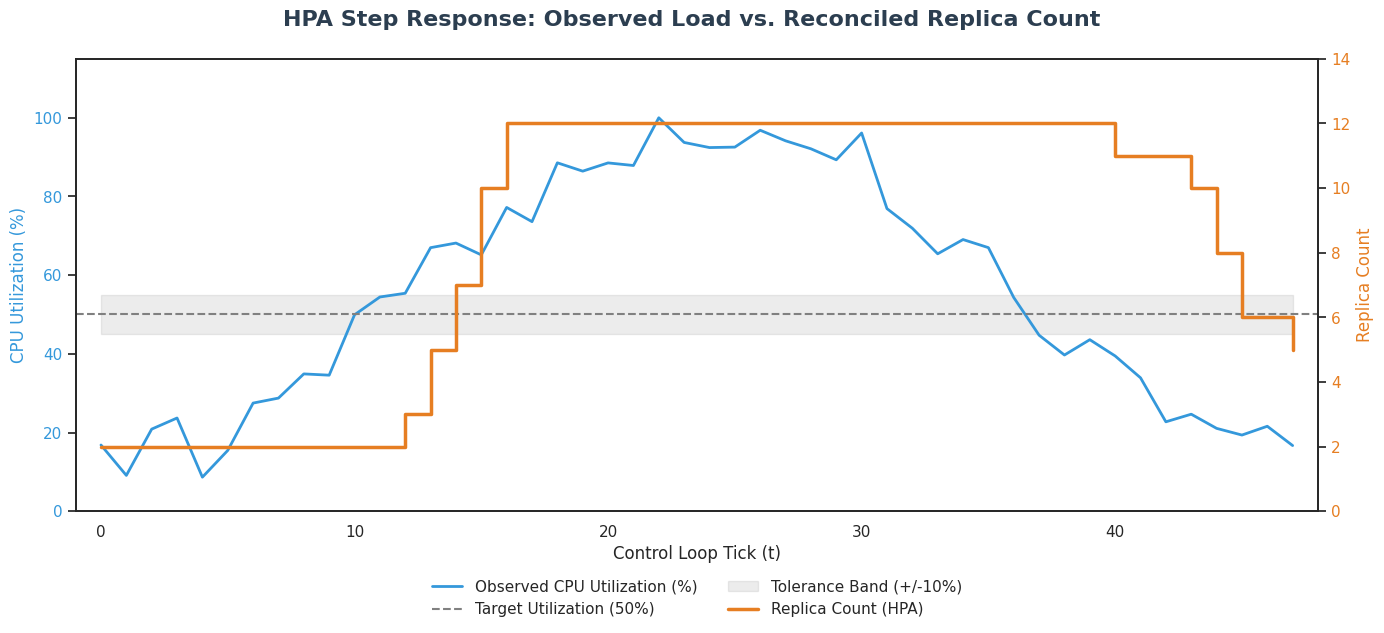

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax1 = plt.subplots(figsize=(14, 6.5))
fig.suptitle("HPA Step Response: Observed Load vs. Reconciled Replica Count", fontsize=16, fontweight='bold', color="#2c3e50")

color_util = "#3498db"
ax1.plot(steps, observed_util, color=color_util, lw=2, label="Observed CPU Utilization (%)")
ax1.axhline(TARGET_UTIL, color="gray", ls="--", lw=1.5, label="Target Utilization (50%)")
ax1.fill_between(steps, TARGET_UTIL * (1 - TOLERANCE), TARGET_UTIL * (1 + TOLERANCE), color="gray", alpha=0.15, label="Tolerance Band (+/-10%)")
ax1.set_xlabel("Control Loop Tick (t)")
ax1.set_ylabel("CPU Utilization (%)", color=color_util)
ax1.tick_params(axis='y', labelcolor=color_util)
ax1.set_ylim(0, 115)
ax1.set_xlim(-1, 48)

ax2 = ax1.twinx()
color_rep = "#e67e22"
ax2.step(steps, replica_history, where="post", color=color_rep, lw=2.5, label="Replica Count (HPA)")
ax2.set_ylabel("Replica Count", color=color_rep)
ax2.tick_params(axis='y', labelcolor=color_rep)
ax2.set_ylim(0, MAX_REPLICAS + 2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


*(Insight: The blue curve is the raw signal the controller observes; the orange step function is its reconciled response. Notice the orange line climbs almost in lock-step with blue spikes above the gray band (fast scale-up) but flattens into wide plateaus on the way down (damped scale-down from the stabilization window) -- the asymmetric control law from Section 1 made visible as two different rates of change on the same axis.)*

## Real-World Use Case or Analogy

Think of HPA and VPA as **The Restaurant Staffing Algorithm**:

* **CPU/Memory Requests (The Table Reservation):** When you request a table for 4, the restaurant reserves exactly that much floor space -- a fixed "resource request" made before anyone sits down, identical to Lesson 01's static Pod request.
* **HPA (The Shift Manager Calling in Extra Waiters):** As the dinner rush ratio of (customers waiting / customers a waiter can serve) climbs past target, the shift manager calls in more waiters -- proportionally, not just "one more." If load doubles, staff roughly doubles.
* **The Tolerance Band (Not Overreacting to One Loud Table):** The manager doesn't reshuffle staffing because one table complained once -- only a sustained deviation outside normal variance triggers a call-in.
* **The Stabilization Window (Never Sending Someone Home Mid-Rush):** The manager calls in help the instant it's needed, but only sends someone home after confirming the slow period has held for a while -- exactly the max-lookback asymmetry that protects against a false "quiet moment."
* **VPA (Widening a Chronically Cramped Table):** If Table 12 is booked by a party of 6 every single week despite being reserved as a 4-top, the restaurant permanently reassigns it a bigger table based on historical demand (the P90 usage recommendation) rather than reacting shift-by-shift.
* **CFS Throttling vs. OOM Kill (A Slow Kitchen vs. a Fire Marshal Shutdown):** An under-resourced kitchen just serves food slower during a rush (throttling, recoverable) -- but if the dining room physically exceeds fire-code capacity (a hard memory limit), the fire marshal shuts it down immediately, no negotiation (OOM kill).

Static requests answer "how much space does this need on a normal night?" HPA and VPA answer the harder, continuous question: "given what is actually happening right now, and what has happened historically, how much capacity should exist at this exact moment?" 